In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42

In [5]:
DATASET_PATH = Path('data')
PROCESSED_PATH = DATASET_PATH / 'processed'
MODELS_PATH = DATASET_PATH / 'models'
REPORTS_PATH = DATASET_PATH / 'reports'

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

TRAIN_BASELINE_PATH = PROCESSED_PATH / '02_train_baseline.csv'
VAL_BASELINE_PATH = PROCESSED_PATH / '02_val_baseline.csv'

print('Train baseline existe:', TRAIN_BASELINE_PATH.exists())
print('Val baseline existe:', VAL_BASELINE_PATH.exists())


Train baseline existe: True
Val baseline existe: True


In [6]:
train_df = pd.read_csv(TRAIN_BASELINE_PATH)
val_df = pd.read_csv(VAL_BASELINE_PATH)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)

display(train_df.head())


Train: (176, 10)
Validation: (44, 10)


,pair_id,language,file_1,file_2,code_1_norm,code_2_norm,jaccard_norm,token_overlap_norm,relative_token_count_diff,label
0,train_pair_000127,java,071.java,021.java,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . ID . ID . * ; IMPORT ID . ID . ID . ...,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ; IMPORT ID . ID . * ; PUBLIC CLASS ID...,0.673077,0.970516,0.589718,0
1,train_pair_000028,java,051.java,258.java,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ....,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; PUBLIC CLASS ID ...,0.826923,0.986607,0.348206,1
2,train_pair_000134,java,051.java,257.java,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ....,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; PUBLIC CLASS ID ...,0.826923,0.856070,0.225024,1
3,train_pair_000037,c,014.c,032.c,"INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID / ID . ID > ID ID NUM ID ID NUM INT ID ( INT ID , INT * ID ) ; ...",INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID . ID > INT ( ) { ID ( STR ID ID STR ID ID ....,0.486486,0.845455,0.836066,0
4,train_pair_000015,java,160.java,009.java,IMPORT ID . ID . * ; PUBLIC CLASS ID { PUBLIC STATIC VOID ID ( STRING [ ] ID ) { STRING ID = NEW STRING ( ) ; STRING...,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; PUBLIC CLASS ID ...,0.709677,0.821429,0.325301,0


In [7]:
required_columns = [
    'pair_id',
    'language',
    'file_1',
    'file_2',
    'code_1_norm',
    'code_2_norm',
    'jaccard_norm',
    'token_overlap_norm',
    'relative_token_count_diff',
    'label'
]

for df_name, df in [('train_df', train_df), ('val_df', val_df)]:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f'{df_name} no tiene estas columnas: {missing}')

print('Columnas validadas correctamente.')


Columnas validadas correctamente.


In [8]:
print('Distribución de clases - Train')
display(train_df['label'].value_counts())

print('\nDistribución de clases - Validation')
display(val_df['label'].value_counts())

print('\nLenguajes - Train')
display(train_df['language'].value_counts())

print('\nLenguajes - Validation')
display(val_df['language'].value_counts())


Distribución de clases - Train


label
0    88
1    88
Name: count, dtype: int64


Distribución de clases - Validation


label
1    22
0    22
Name: count, dtype: int64


Lenguajes - Train


language
java    109
c        67
Name: count, dtype: int64


Lenguajes - Validation


language
java    26
c       18
Name: count, dtype: int64

In [9]:
train_df['code_1_norm'] = train_df['code_1_norm'].fillna('')
train_df['code_2_norm'] = train_df['code_2_norm'].fillna('')
val_df['code_1_norm'] = val_df['code_1_norm'].fillna('')
val_df['code_2_norm'] = val_df['code_2_norm'].fillna('')

all_train_code = pd.concat([
    train_df['code_1_norm'],
    train_df['code_2_norm']
], ignore_index=True)

print('Total textos para ajustar TF-IDF:', len(all_train_code))
all_train_code.head()


Total textos para ajustar TF-IDF: 352


0    IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . ID . ID . * ; IMPORT ID . ID . ID . ...
1    IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ....
2    IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ....
3    INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID / ID . ID > ID ID NUM ID ID NUM INT ID ( INT ID , INT * ID ) ; ...
4    IMPORT ID . ID . * ; PUBLIC CLASS ID { PUBLIC STATIC VOID ID ( STRING [ ] ID ) { STRING ID = NEW STRING ( ) ; STRING...
dtype: str

In [10]:
tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    min_df=1,
    max_df=0.95,
    max_features=20000,
    lowercase=False
)

tfidf.fit(all_train_code)

print('Tamaño del vocabulario:', len(tfidf.vocabulary_))


Tamaño del vocabulario: 1677


In [11]:
numeric_feature_columns = [
    'jaccard_norm',
    'token_overlap_norm',
    'relative_token_count_diff'
]

def build_feature_matrix(df, vectorizer):
    X1 = vectorizer.transform(df['code_1_norm'].fillna(''))
    X2 = vectorizer.transform(df['code_2_norm'].fillna(''))
    X_abs_diff = abs(X1 - X2)

    X_numeric = df[numeric_feature_columns].fillna(0).astype(float).values
    X_numeric_sparse = csr_matrix(X_numeric)

    X = hstack([X1, X2, X_abs_diff, X_numeric_sparse])
    return X

X_train = build_feature_matrix(train_df, tfidf)
X_val = build_feature_matrix(val_df, tfidf)

y_train = train_df['label'].astype(int).values
y_val = val_df['label'].astype(int).values

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)


X_train: (176, 5034)
X_val: (44, 5034)
y_train: (176,)
y_val: (44,)


In [12]:
def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f'===== {model_name} =====')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print('Matriz de confusión:')
    print(cm)

    return {
        'model': model_name,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tn': cm[0, 0] if cm.shape == (2, 2) else np.nan,
        'fp': cm[0, 1] if cm.shape == (2, 2) else np.nan,
        'fn': cm[1, 0] if cm.shape == (2, 2) else np.nan,
        'tp': cm[1, 1] if cm.shape == (2, 2) else np.nan
    }


def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Etiqueta real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No reuso', 'Reuso'])
    ax.set_yticklabels(['No reuso', 'Reuso'])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')

    fig.colorbar(im)
    plt.tight_layout()
    plt.show()


===== Logistic Regression =====
Accuracy : 0.9091
Precision: 0.8750
Recall   : 0.9545
F1-score : 0.9130

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.88      0.95      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44

Matriz de confusión:
[[19  3]
 [ 1 21]]


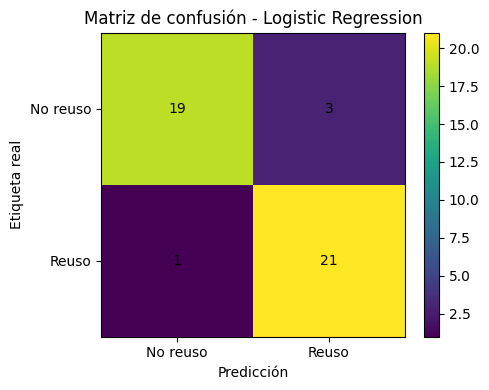

In [13]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_val)

results = []
results.append(evaluate_model('Logistic Regression', y_val, y_pred_log_reg))

cm_log_reg = confusion_matrix(y_val, y_pred_log_reg)
plot_confusion_matrix(cm_log_reg, 'Matriz de confusión - Logistic Regression')


===== Linear SVM =====
Accuracy : 0.9318
Precision: 0.8800
Recall   : 1.0000
F1-score : 0.9362

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        22
           1       0.88      1.00      0.94        22

    accuracy                           0.93        44
   macro avg       0.94      0.93      0.93        44
weighted avg       0.94      0.93      0.93        44

Matriz de confusión:
[[19  3]
 [ 0 22]]


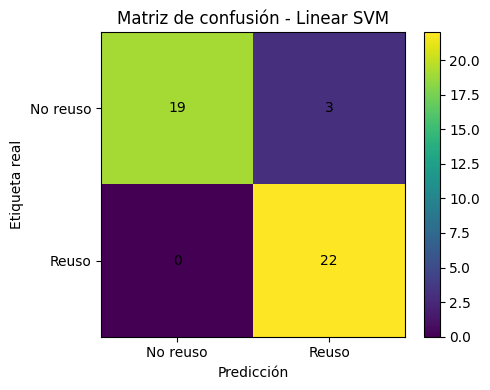

In [14]:
linear_svm = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=5000
)

linear_svm.fit(X_train, y_train)

y_pred_svm = linear_svm.predict(X_val)

results.append(evaluate_model('Linear SVM', y_val, y_pred_svm))

cm_svm = confusion_matrix(y_val, y_pred_svm)
plot_confusion_matrix(cm_svm, 'Matriz de confusión - Linear SVM')


===== Random Forest Simple Features =====
Accuracy : 0.8636
Precision: 0.8636
Recall   : 0.8636
F1-score : 0.8636

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        22
           1       0.86      0.86      0.86        22

    accuracy                           0.86        44
   macro avg       0.86      0.86      0.86        44
weighted avg       0.86      0.86      0.86        44

Matriz de confusión:
[[19  3]
 [ 3 19]]


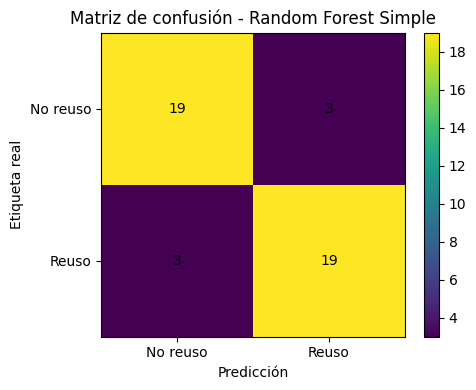

In [15]:
X_train_simple = train_df[numeric_feature_columns].fillna(0).astype(float).values
X_val_simple = val_df[numeric_feature_columns].fillna(0).astype(float).values

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

rf.fit(X_train_simple, y_train)

y_pred_rf = rf.predict(X_val_simple)

results.append(evaluate_model('Random Forest Simple Features', y_val, y_pred_rf))

cm_rf = confusion_matrix(y_val, y_pred_rf)
plot_confusion_matrix(cm_rf, 'Matriz de confusión - Random Forest Simple')


In [16]:
results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False).reset_index(drop=True)
display(results_df)

results_df.to_csv(REPORTS_PATH / '03_baseline_model_results.csv', index=False)


,model,accuracy,precision,recall,f1,tn,fp,fn,tp
0,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22
1,Logistic Regression,0.909091,0.875000,0.954545,0.913043,19,3,1,21
2,Random Forest Simple Features,0.863636,0.863636,0.863636,0.863636,19,3,3,19


In [17]:
best_model_name = results_df.iloc[0]['model']
print('Mejor modelo:', best_model_name)

if best_model_name == 'Logistic Regression':
    best_model = log_reg
    best_model_type = 'tfidf_full'
elif best_model_name == 'Linear SVM':
    best_model = linear_svm
    best_model_type = 'tfidf_full'
else:
    best_model = rf
    best_model_type = 'simple_features'

print('Tipo de features del mejor modelo:', best_model_type)


Mejor modelo: Linear SVM
Tipo de features del mejor modelo: tfidf_full


In [18]:
model_bundle = {
    'best_model_name': best_model_name,
    'best_model_type': best_model_type,
    'model': best_model,
    'tfidf': tfidf,
    'numeric_feature_columns': numeric_feature_columns,
    'results': results_df.to_dict(orient='records')
}

joblib.dump(model_bundle, MODELS_PATH / '03_baseline_model.joblib')

print('Modelo guardado en:', MODELS_PATH / '03_baseline_model.joblib')


Modelo guardado en: data\models\03_baseline_model.joblib


In [19]:
def predict_pairs(df, model_bundle):
    model = model_bundle['model']
    model_type = model_bundle['best_model_type']
    vectorizer = model_bundle['tfidf']
    numeric_cols = model_bundle['numeric_feature_columns']

    if model_type == 'tfidf_full':
        X = build_feature_matrix(df, vectorizer)
    else:
        X = df[numeric_cols].fillna(0).astype(float).values

    preds = model.predict(X)

    output = df[['pair_id', 'language', 'file_1', 'file_2']].copy()
    output['prediction'] = preds
    output['prediction_label'] = output['prediction'].map({0: 'No reuso', 1: 'Reuso'})

    if hasattr(model, 'predict_proba'):
        output['prob_reuse'] = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        output['decision_score'] = scores

    return output


sample_predictions = predict_pairs(val_df.head(10), model_bundle)
display(sample_predictions)


,pair_id,language,file_1,file_2,prediction,prediction_label,decision_score
0,train_pair_000181,java,242.java,243.java,1,Reuso,1.080750
1,train_pair_000174,java,107.java,113.java,1,Reuso,1.122656
2,train_pair_000026,java,191.java,193.java,1,Reuso,0.468591
3,train_pair_000042,c,015.c,020.c,0,No reuso,-1.096508
4,train_pair_000169,java,086.java,242.java,1,Reuso,1.083637
5,train_pair_000044,java,136.java,173.java,1,Reuso,0.127913
6,train_pair_000197,c,013.c,045.c,0,No reuso,-0.255292
7,train_pair_000085,java,135.java,174.java,1,Reuso,0.344382
8,train_pair_000071,java,016.java,024.java,1,Reuso,1.223334
9,train_pair_000070,java,086.java,240.java,1,Reuso,0.829107


In [20]:
val_predictions = predict_pairs(val_df, model_bundle)
val_predictions['true_label'] = y_val

val_predictions.to_csv(REPORTS_PATH / '03_val_predictions_baseline.csv', index=False)

display(val_predictions.head())
print('Predicciones guardadas en:', REPORTS_PATH / '03_val_predictions_baseline.csv')


,pair_id,language,file_1,file_2,prediction,prediction_label,decision_score,true_label
0,train_pair_000181,java,242.java,243.java,1,Reuso,1.080750,1
1,train_pair_000174,java,107.java,113.java,1,Reuso,1.122656,1
2,train_pair_000026,java,191.java,193.java,1,Reuso,0.468591,1
3,train_pair_000042,c,015.c,020.c,0,No reuso,-1.096508,0
4,train_pair_000169,java,086.java,242.java,1,Reuso,1.083637,1


Predicciones guardadas en: data\reports\03_val_predictions_baseline.csv
